# Social Network Analysis with R — Practical

**Dataset:** `member-edges.csv` (Meetup member-to-member network)

### Objective
Represent members as **nodes** and member relationships as **edges**, construct the social network, calculate network measures, identify highly connected/influential members, visualize the network, and interpret the results.


## 1. Install and load required R packages

In [ ]:
install.packages(c("igraph", "ggplot2"), repos = "https://cloud.r-project.org")

# Load packages
library(igraph)
library(ggplot2)

set.seed(123)
options(stringsAsFactors = FALSE)


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




## 2. Check that the CSV file is uploaded

In [ ]:
csv_path <- "/content/member-edges.csv"

if (!file.exists(csv_path)) {
  stop("member-edges.csv was not found. Upload the CSV using Colab's Files panel and run this cell again.")
}

cat("File found:", csv_path, "\n")
cat("File size:", round(file.info(csv_path)$size / 1024^2, 2), "MB\n")


File found: /content/member-edges.csv 
File size: 32.87 MB


## 3. Import and inspect the dataset

In [ ]:
edges <- read.csv(csv_path, header = TRUE)

# Remove the unnecessary CSV index column if present
if ("Unnamed..0" %in% names(edges)) {
  edges$Unnamed..0 <- NULL
}
if ("Unnamed: 0" %in% names(edges)) {
  edges$`Unnamed: 0` <- NULL
}

# Display basic information
cat("Rows (edges):", nrow(edges), "\n")
cat("Columns:", paste(names(edges), collapse = ", "), "\n\n")

print(head(edges))
str(edges)


Rows (edges): 1176368 
Columns: X, member1, member2, weight 

  X   member1   member2 weight
1 0 198737924 220654721      1
2 1 198737924 208201738      1
3 2 198737924  88664332      1
4 3 198737924   8640526      1
5 4 198737924  56356372      1
6 5 198737924 183880473      1
'data.frame':	1176368 obs. of  4 variables:
 $ X      : int  0 1 2 3 4 5 6 7 8 9 ...
 $ member1: int  198737924 198737924 198737924 198737924 198737924 198737924 198737924 198737924 198737924 198737924 ...
 $ member2: int  220654721 208201738 88664332 8640526 56356372 183880473 194617630 185626278 8809394 193825984 ...
 $ weight : int  1 1 1 1 1 1 1 1 1 1 ...


## 4. Data preparation

The important columns are:

- `member1` → source member
- `member2` → connected member
- `weight` → relationship weight

For this practical, `member1` and `member2` form the **edge list**. The network is treated as **undirected**, because the relationship represents a connection between two members.


In [ ]:
# Keep only valid member-to-member relationships
edges <- edges[!is.na(edges$member1) & !is.na(edges$member2), ]

# Convert member IDs to character labels
edges$member1 <- as.character(edges$member1)
edges$member2 <- as.character(edges$member2)

# Remove self-loops
edges <- edges[edges$member1 != edges$member2, ]

# Remove duplicate pairs while keeping the first observed weight
edges <- edges[!duplicated(edges[, c("member1", "member2")]), ]

cat("Edges after cleaning:", nrow(edges), "\n")
cat("Unique members:", length(unique(c(edges$member1, edges$member2))), "\n")


Edges after cleaning: 1176368 
Unique members: 11372 


## 5. Create the social network

In [ ]:
# Create an undirected graph from the edge list
g <- graph_from_data_frame(
  d = edges[, c("member1", "member2")],
  directed = FALSE
)

cat("Number of nodes:", vcount(g), "\n")
cat("Number of edges:", ecount(g), "\n")
cat("Is the graph directed?", is_directed(g), "\n")


Number of nodes: 11372 
Number of edges: 1176368 
Is the graph directed? FALSE 


## 6. Basic network characteristics

In [ ]:
# Basic network measures
network_density <- edge_density(g)
avg_degree <- mean(degree(g))
components <- components(g)

cat("Number of nodes:", vcount(g), "\n")
cat("Number of edges:", ecount(g), "\n")
cat("Network density:", round(network_density, 6), "\n")
cat("Average degree:", round(avg_degree, 2), "\n")
cat("Number of connected components:", components$no, "\n")
cat("Largest component size:", max(components$csize), "\n")


Number of nodes: 11372 
Number of edges: 1176368 
Network density: 0.018194 
Average degree: 206.89 
Number of connected components: 1 
Largest component size: 11372 


## 7. Degree centrality — find highly connected members

In [ ]:
# Degree = number of direct connections of each member
degree_values <- degree(g, mode = "all")

degree_results <- data.frame(
  member = names(degree_values),
  degree = as.numeric(degree_values)
)

degree_results <- degree_results[order(-degree_results$degree), ]

cat("Top 10 most connected members:\n")
print(head(degree_results, 10))


Top 10 most connected members:
        member degree
1765   3380276   2356
6653   8539046   1911
2670 221191725   1893
839    5900662   1811
1456  81924252   1775
7510  46486792   1642
3528 197928971   1620
6384 187254868   1568
8432 175300482   1556
4273  15446041   1542


## 8. Betweenness centrality — identify bridge/influential members

In [ ]:
# Exact betweenness on a network with over one million edges can be expensive.
# Therefore, we calculate betweenness on the largest connected component.
largest_component_id <- which.max(components$csize)
g_largest <- induced_subgraph(g, V(g)[components$membership == largest_component_id])

cat("Largest component nodes:", vcount(g_largest), "\n")
cat("Largest component edges:", ecount(g_largest), "\n")

# Approximate betweenness for efficiency.
# k controls how many source vertices are sampled.
k <- min(1000, vcount(g_largest))

set.seed(123)
sample_sources <- sample(V(g_largest), k)

bet <- estimate_betweenness(
  g_largest,
  vids = V(g_largest),
  directed = FALSE,
  cutoff = 4,
  weights = NA
)

bet_results <- data.frame(
  member = V(g_largest)$name,
  betweenness = as.numeric(bet)
)

bet_results <- bet_results[order(-bet_results$betweenness), ]

cat("Top 10 members by approximate betweenness:\n")
print(head(bet_results, 10))


Largest component nodes: 11372 
Largest component edges: 1176368 


Warning message:
“`estimate_betweenness()` was deprecated in igraph 1.6.0.
ℹ Please use `betweenness()` instead.
ℹ with the cutoff argument.”


Top 10 members by approximate betweenness:
        member betweenness
5972   3949436   1430431.0
6653   8539046   1296114.3
839    5900662   1245640.3
3528 197928971   1037406.2
8432 175300482   1018833.9
2670 221191725    889106.8
1456  81924252    773244.2
1765   3380276    770941.5
4149 144256692    734388.8
7510  46486792    712912.5


## 9. Closeness centrality — identify centrally located members

In [ ]:
# Closeness is calculated on the largest connected component.
# cutoff limits the search distance for a faster calculation.

close_values <- closeness(
  g_largest,
  mode = "all",
  normalized = TRUE,
  cutoff = 4
)

close_results <- data.frame(
  member = V(g_largest)$name,
  closeness = as.numeric(close_values)
)

close_results <- close_results[order(-close_results$closeness), ]

cat("Top 10 members by closeness:\n")
print(head(close_results, 10))


Top 10 members by closeness:
        member closeness
1765   3380276 0.5471562
2670 221191725 0.5350555
6653   8539046 0.5315787
839    5900662 0.5295981
1456  81924252 0.5254135
6384 187254868 0.5249769
4872 166082312 0.5222763
346  209224665 0.5215098
7510  46486792 0.5207694
8432 175300482 0.5163707


## 10. Combine centrality results

In [ ]:
# Combine degree, betweenness and closeness for the largest component
centrality_results <- merge(
  degree_results,
  bet_results,
  by = "member",
  all.x = TRUE
)

centrality_results <- merge(
  centrality_results,
  close_results,
  by = "member",
  all.x = TRUE
)

centrality_results <- centrality_results[order(-centrality_results$degree), ]

cat("Centrality summary for top 10 members by degree:\n")
print(head(centrality_results, 10))


Centrality summary for top 10 members by degree:
         member degree betweenness closeness
9352    3380276   2356    770941.5 0.5471562
10863   8539046   1911   1296114.3 0.5315787
7572  221191725   1893    889106.8 0.5350555
10053   5900662   1811   1245640.3 0.5295981
10730  81924252   1775    773244.2 0.5254135
9703   46486792   1642    712912.5 0.5207694
4566  197928971   1620   1037406.2 0.5162301
3193  187254868   1568    521461.3 0.5249769
2315  175300482   1556   1018833.9 0.5163707
1883   15446041   1542    290735.7 0.5062778


## 11. Visualize the complete network structure

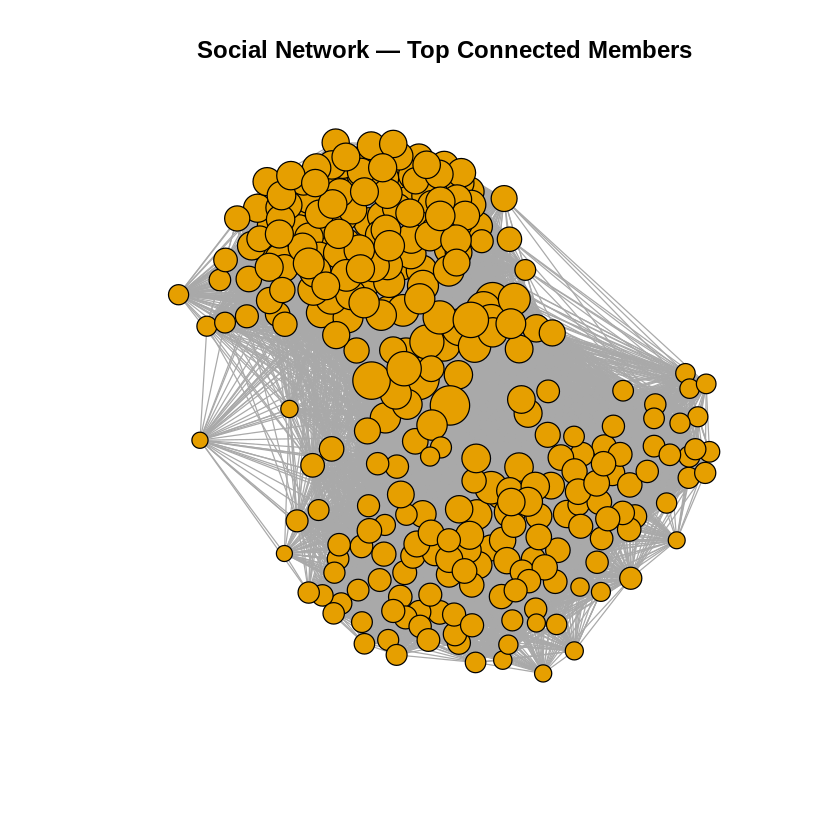

In [ ]:
# For a network of this size, plotting every node and edge is not practical.
# We therefore visualize a representative sample while keeping all-network
# calculations above.

set.seed(123)

# Select up to 300 members with the highest degree
n_plot_nodes <- min(300, vcount(g))
top_members <- degree_results$member[1:n_plot_nodes]

# Include edges only when both endpoints are in the selected set
g_plot <- induced_subgraph(g, vids = top_members)

# Scale node size by degree within the plotted graph
plot_degree <- degree(g_plot)

# Plot the sampled/high-degree portion of the network
set.seed(123)
plot(
  g_plot,
  layout = layout_with_fr(g_plot),
  vertex.size = 4 + 12 * (plot_degree / max(plot_degree)),
  vertex.label = NA,
  edge.arrow.size = 0.2,
  main = "Social Network — Top Connected Members"
)


## 12. Visualize the top 20 most connected members

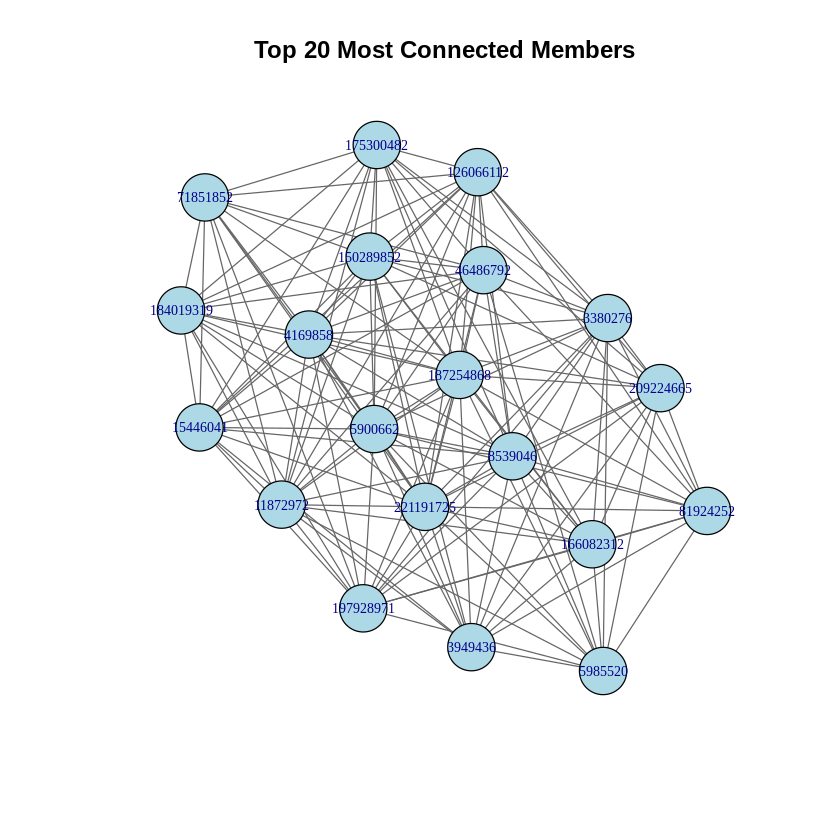

In [ ]:
# A smaller graph makes individual connections easier to see.
top20 <- degree_results$member[1:min(20, nrow(degree_results))]

g_top20 <- induced_subgraph(g, vids = top20)

set.seed(123)
plot(
  g_top20,
  layout = layout_with_fr(g_top20),
  vertex.size = 18,
  vertex.color = "lightblue",
  vertex.frame.color = "black",
  vertex.label.cex = 0.7,
  edge.color = "gray40",
  main = "Top 20 Most Connected Members"
)


## 13. Degree distribution

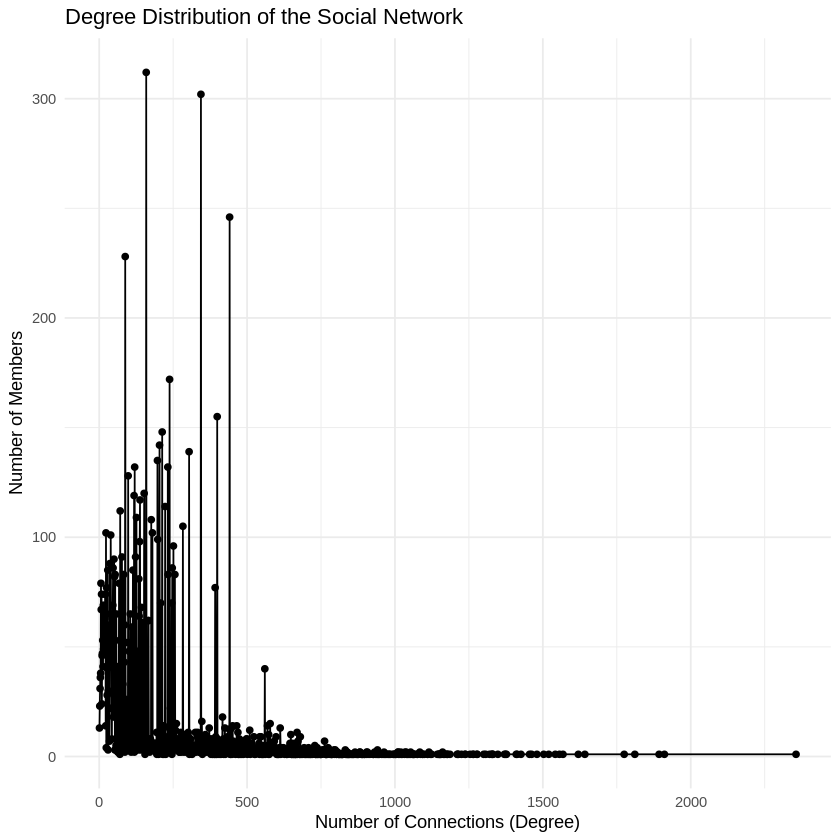

In [ ]:
# Prepare degree distribution
degree_frequency <- as.data.frame(table(degree_values))
names(degree_frequency) <- c("degree", "frequency")
degree_frequency$degree <- as.numeric(as.character(degree_frequency$degree))

ggplot(degree_frequency, aes(x = degree, y = frequency)) +
  geom_point() +
  geom_line() +
  labs(
    title = "Degree Distribution of the Social Network",
    x = "Number of Connections (Degree)",
    y = "Number of Members"
  ) +
  theme_minimal()


## 14. Save the analysis results

In [ ]:
# Save the important results as CSV files in Colab
write.csv(degree_results, "/content/degree_centrality_results.csv", row.names = FALSE)
write.csv(bet_results, "/content/betweenness_results.csv", row.names = FALSE)
write.csv(close_results, "/content/closeness_results.csv", row.names = FALSE)
write.csv(centrality_results, "/content/centrality_summary.csv", row.names = FALSE)

cat("Result files created in /content:\n")
cat("- degree_centrality_results.csv\n")
cat("- betweenness_results.csv\n")
cat("- closeness_results.csv\n")
cat("- centrality_summary.csv\n")


Result files created in /content:
- degree_centrality_results.csv
- betweenness_results.csv
- closeness_results.csv
- centrality_summary.csv


## 15. Final interpretation

Use the generated results to write observations such as:

1. The **degree** measure identifies members with the largest number of direct connections.
2. Members with high **betweenness centrality** can act as bridges between different parts of the network.
3. High **closeness centrality** indicates members that are relatively centrally positioned within the connected component.
4. The network visualization shows how members are connected and helps reveal highly connected regions.
5. The exact member IDs and numerical values in the final report should be taken from the outputs generated above.

### Conclusion

The Meetup member relationship data was successfully represented as a social network in R. Members were modeled as nodes and member relationships as edges. Network characteristics and centrality measures were calculated, highly connected/influential members were identified, and the network structure was visualized.
